---
# IPYNB Notebook for Model Evaluation

#### The ViZDoom Experience
###### An Individual Project Undertaken by Rhys Stewart

---

## Imports

In [39]:
# !pip install pandas
# !pip install seaborn
# !pip install pathlib
# !pip install scipy
#!pip install statannotations
#!pip install tabulate

In [1]:
# === IMPORTS ===
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import re
import matplotlib.pyplot as plt

---

## Functions

---
### File/Directory Functions

In [3]:
def get_proj_root():
    # Grab the directory the notebook is currently running in
    curr_path = Path.cwd().resolve()
    
    for parent in [curr_path] + list(curr_path.parents):
        if (parent / ".git").exists() or (parent / "requirements.txt").exists():
            return parent
            
    raise FileNotFoundError("Could not locate project root directory")

---
### Metric Calculations

In [4]:
def calculate_metrics(rewards, success_threshold=-5.0):
    
    """Calculates the core scientific metrics for the evaluation tables."""
    
    rewards = np.array(rewards)
    
    return {
        "Mean": np.mean(rewards),
        "SD": np.std(rewards),
        "Min": np.min(rewards),
        "Max": np.max(rewards),
        "Success Rate (%)": np.mean(rewards > success_threshold) * 100
    }

---
### Data Loading/Parsing

In [5]:
def parse_rewards_file(filepath):
    """Parses the text file to extract episode rewards using regex."""
    with open(filepath, 'r') as file:
        content = file.read()
    
    # Regex to find all reward values. Matches: 'Episode X': <value>
    # captures positive, negative, integer, and float numbers
    rewards = re.findall(r"'Episode \d+':\s*([-+]?[0-9]*\.?[0-9]+)", content)

    return [float(r) for r in rewards]

In [6]:
def load_data(root_dir):
    """Traverses the directory structure and compiles data into a DataFrame."""
    data = []
    root_path = Path(root_dir)
    
    if not root_path.exists():
        raise FileNotFoundError(f"Directory {root_dir} not found.")

    for filepath in root_path.rglob('*.txt'):
        if filepath.is_file():
            
            filename = filepath.stem
            
            if filename.startswith("active"):
                model_type = "Active"
            elif filename.startswith("baseline"):
                model_type = "Baseline"
            else:
                continue 
                
            trained_match = re.search(r'lvl_(\d+)', filename)
            trained_level = f"Level {trained_match.group(1)}" if trained_match else "Unknown"
            
            eval_match = re.search(r'_on_(?:lvl_)?(\d+)', filename)
            eval_level = f"Level {eval_match.group(1)}" if eval_match else trained_level
            
            reduction = "None"
            if model_type == "Active":
                reduction_match = re.search(r'_(\d+)_model', filename)
                if reduction_match:
                    reduction = f"{reduction_match.group(1)}%"
            
            rewards = parse_rewards_file(filepath)
            
            for ep_num, reward in enumerate(rewards):
                data.append({
                    'Model_Type': model_type,
                    'Trained_Level': trained_level,
                    'Evaluated_Level': eval_level,
                    'Reduction': reduction,
                    'Episode': ep_num,
                    'Reward': reward,
                    'Filename': filepath.name
                })
                
    return pd.DataFrame(data)

In [7]:
def parse_txt_to_dataframes(filepath):
    """Parses a text file with Markdown tables into a list of DataFrames."""
    with open(filepath, 'r') as f:
        lines = f.readlines()

    tables = []
    current_title = None
    current_data = []
    headers = None

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # 1. Identify the start of a new table
        if line.startswith("--- Summary Table:"):
            # If we were already building a table, save it before starting the new one
            if current_title and current_data:
                df = pd.DataFrame(current_data, columns=headers)
                tables.append((current_title, df))

            # Extract the new title (removes the '---' and leading/trailing spaces)
            current_title = line.strip("- ").strip()
            current_data = []
            headers = None
            continue

        # 2. Extract the table rows
        if line.startswith("|"):
            # Split by the pipe character and clean up whitespace
            # [1:-1] removes the empty strings created by the outer pipes
            row = [cell.strip() for cell in line.split("|")][1:-1]

            if headers is None:
                headers = row
            elif "---" in line or ":--" in line: 
                # Skip the Markdown formatting row (e.g., |:---|---:|)
                continue
            else:
                current_data.append(row)

    # Don't forget to save the very last table in the file!
    if current_title and current_data:
         df = pd.DataFrame(current_data, columns=headers)
         tables.append((current_title, df))

    return tables

---
### Tables

In [8]:
def create_summary_table(df, level="Level 1", success_threshold=-5.0, trained_level = "Level 1"):
    """Generates a summary table for a specific level with logical ordering."""
    
    # 1. Filter for the specific level
    df_level = df[df['Evaluated_Level'] == level].copy()
    
    # 2. Create the clean "Configuration" label
    df_level['Configuration'] = df_level.apply(
        lambda row: "Baseline" if row['Model_Type'] == "Baseline" 
        else f"Active ({int(str(row['Reduction']).strip('% '))}% FOV)", axis=1
    )
    
    # 3. Define the logical sort order
    # This matches the specific labels created in the step above
    desired_order = [
        "Baseline",
        "Active (1% FOV)",
        "Active (5% FOV)",
        "Active (10% FOV)",
        "Active (20% FOV)",
        "Active (40% FOV)",
        "Active (60% FOV)",
        "Active (80% FOV)",
        "Active (100% FOV)"
    ]
    
    # 4. Filter the desired_order to only include categories present in the data
    existing_configs = [c for c in desired_order if c in df_level['Configuration'].unique()]
    
    # 5. Convert Configuration to a Categorical type with the specified order
    df_level['Configuration'] = pd.Categorical(
        df_level['Configuration'], 
        categories=existing_configs, 
        ordered=True
    )
    
    # 6. Calculate metrics using Pandas GroupBy
    # Grouping by a Categorical column preserves the category order
    summary = df_level.groupby('Configuration', observed=False)['Reward'].agg(
        Mean='mean',
        SD='std',
        Min='min',
        Max='max'
    ).reset_index()
    
    # 7. Calculate Success Rate
    success_rates = df_level.groupby('Configuration', observed=False).apply(
        lambda x: (x['Reward'] > success_threshold).mean() * 100,
        include_groups=False
    ).reset_index(name='Success Rate (%)')
    
    # 8. Merge and print
    summary = pd.merge(summary, success_rates, on='Configuration')
    print(f"\n--- Summary Table: {level}, Trained on: {trained_level} ---")
    print(summary.to_markdown(index=False, floatfmt=".2f"))
    
    return summary

In [9]:
def create_summary_tables(df, level="Level 1", success_thresholds=[-5, 0, 5, 10, 15, 20], trained_level = "Level 1"):
    """Generates and prints separate summary tables for each success threshold."""
    
    # 1. Filter for the specific level
    df_level = df[df['Evaluated_Level'] == level].copy()
    
    # 2. Create the clean "Configuration" label
    df_level['Configuration'] = df_level.apply(
        lambda row: "Baseline" if row['Model_Type'] == "Baseline" 
        else f"Active ({int(str(row['Reduction']).strip('% '))}% FOV)", axis=1
    )
    
    # 3. Define the logical sort order
    desired_order = [
        "Baseline",
        "Active (1% FOV)",
        "Active (5% FOV)",
        "Active (10% FOV)",
        "Active (20% FOV)",
        "Active (40% FOV)",
        "Active (60% FOV)",
        "Active (80% FOV)",
        "Active (100% FOV)"
    ]
    
    # 4. Filter categories
    existing_configs = [c for c in desired_order if c in df_level['Configuration'].unique()]
    
    # 5. Convert to Categorical
    df_level['Configuration'] = pd.Categorical(
        df_level['Configuration'], 
        categories=existing_configs, 
        ordered=True
    )
    
    # 6. Calculate static metrics
    base_summary = df_level.groupby('Configuration', observed=False)['Reward'].agg(
        Mean='mean',
        SD='std',
        Min='min',
        Max='max'
    ).reset_index()
    
    # Dictionary to store the individual tables so you can access them later
    all_tables = {}
    
    # 7. Iterate through each threshold, merge with base metrics, and print
    for thresh in success_thresholds:
        
        # Calculate success rate for just this threshold
        success_rates = df_level.groupby('Configuration', observed=False).apply(
            lambda x: (x['Reward'] >= thresh).mean() * 100,
            include_groups=False
        ).reset_index(name='Success Rate (%)')
        
        # Merge this specific success rate with the base summary
        threshold_summary = pd.merge(base_summary, success_rates, on='Configuration')
        
        # Print the individual table
        print(f"\n--- Summary Table: {level}, Trained on {trained_level} | Success Threshold >= {thresh} ---")
        print(threshold_summary.to_markdown(index=False, floatfmt=".2f"))
        
        # Save to our dictionary using the threshold as the key
        all_tables[thresh] = threshold_summary
        
    return all_tables

# === Example Usage ===
# thresholds = [-10, -5, 0, 5, 10]
# level_1_tables = create_summary_tables(df_results, level="Level 1", success_thresholds=thresholds)

In [10]:
def save_table_as_pdf(df, title, output_dir):
    """Renders a DataFrame as a styled table and saves it as a PDF."""
    
    # Generate a safe filename from the title
    # E.g., replaces " >= " with "_gte_" and removes illegal characters
    safe_name = title.replace(" >= ", "_gte_").replace(" | ", "_")
    safe_name = "".join([c for c in safe_name if c.isalpha() or c.isdigit() or c == '_' or c == '-'])
    filename = Path(output_dir) / f"{safe_name}.pdf"

    # Set up the figure size dynamically based on the number of rows
    fig, ax = plt.subplots(figsize=(10, df.shape[0] * 0.4 + 1.5))
    ax.axis('off')
    
    # Add the title to the top of the image
    plt.title(title, weight='bold', size=12, pad=15)

    # Create the table visual
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )

    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8) # Stretch cells slightly for readability

    # Apply colors
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            # Header row styling
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#4C72B0') 
        elif row % 2 == 0:
            # Alternating row colors
            cell.set_facecolor('#F3F5F6')

    plt.tight_layout()
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    plt.close() # Close to prevent memory overload
    print(f"Saved: {filename.name}")

In [11]:
def generate_latex_from_tables(extracted_tables, output_file="All_Tables.tex"):
    
    """Converts the parsed DataFrames directly into a LaTeX document."""
    
    with open(output_file, 'w') as f:
        for title, df in extracted_tables:
            f.write(f"% --- {title} ---\n")
            
            # Convert the dataframe to LaTeX format
            # escape=True ensures characters like '%' are properly escaped for LaTeX
            latex_str = df.to_latex(index=False, float_format="%.2f", escape=True)
            
            f.write(latex_str)
            f.write("\n\n")
            
    print(f"LaTeX code saved to {output_file}")

# You can call it right after the parser runs:
# extracted_tables = parse_txt_to_dataframes("Summary_Tables_ALL.txt")
# generate_latex_from_tables(extracted_tables)

---
### Visualisations (Graphs)

In [12]:
def plot_success_rate_trend_from_df_active(df, level="Level 1", trained_level = "Level 1"):
    """Plots how the success rate changes across Active Vision reductions for multiple thresholds."""
    
    # Filter for only Active models on the specified level
    df_active = df[(df['Evaluated_Level'] == level) & (df['Model_Type'] == 'Active')].copy()

    def get_graph(success_thresholds):
        
        # 1. Create the figure ONCE before the loop starts
        plt.figure(figsize=(10, 6))
        
        # Generate a distinct color palette for the number of thresholds
        colors = plt.cm.viridis(np.linspace(0, 0.9, len(success_thresholds)))

        for idx, thresh in enumerate(success_thresholds):
    
            # 2. Use 'thresh' instead of 'success_threshold'
            trend_data = df_active.groupby('Reduction').apply(
                lambda x: (x['Reward'] >= thresh).mean() * 100,
                include_groups=False
            ).reset_index(name='Success_Rate')
            
            # 3. Safely sort by numeric value instead of alphabetical strings
            # This strips the '%' sign, converts to int, sorts, then plots
            trend_data['Numeric_Sort'] = trend_data['Reduction'].astype(str).str.replace('%', '').astype(int)
            trend_data = trend_data.sort_values(by='Numeric_Sort')
        
            # Plot the line on the shared figure
            plt.plot(
                trend_data['Reduction'], 
                trend_data['Success_Rate'], 
                marker='o', 
                linestyle='-', 
                color=colors[idx], 
                markersize=8,
                label=f'Target >= {thresh}' # Add label for the legend
            )
        
        # Formatting applies to the shared figure
        plt.title(f"Impact of FOV Reduction on Success Rate: {level}, Trained on: {trained_level}", pad=15, fontweight='bold')
        plt.ylabel("Success Rate (%)")
        plt.xlabel("FOV Reduction Percentage")
        plt.ylim(-5, 105) # Added a tiny bit of negative padding so 0% doesn't sit exactly on the bottom border
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Add the legend to show which line is which
        plt.legend(title="Success Thresholds", loc='best')
        
        plt.tight_layout()
        plt.savefig(f"Active_success_trend_multiple_{level.replace(' ', '')}.pdf", format='pdf')
        plt.show()

    # Define thresholds and call the inner function
    thresholds = [-5, 0, 5, 10, 15, 20]
    get_graph(thresholds)

In [13]:
def plot_success_rate_trend_baseline(df, level="Level 1", trained_level = "Level 1"):
    """Plots how the success rate changes across different target thresholds for Baseline models."""
    
    # Filter for only Baseline models on the specified level
    df_baseline = df[(df['Evaluated_Level'] == level) & (df['Model_Type'] == 'Baseline')].copy()

    def get_graph(success_thresholds):
        
        # 1. Create the figure
        plt.figure(figsize=(8, 5))
        
        success_rates = []
        
        # 2. Calculate the success rate for each threshold
        for thresh in success_thresholds:
            # Since there is no 'Reduction' to group by, we just calculate the mean of all episodes
            rate = (df_baseline['Reward'] >= thresh).mean() * 100
            success_rates.append(rate)
            
        # 3. Plot the trendline (Thresholds on X-axis, Success Rate on Y-axis)
        plt.plot(
            success_thresholds, 
            success_rates, 
            marker='o', 
            linestyle='-', 
            color='coral',  # Using a distinct color from the active models
            markersize=8,
            linewidth=2,
            #label="Baseline Model"
        )
        
        # Add the exact percentages above each point for easy reading
        for i, rate in enumerate(success_rates):
            plt.text(success_thresholds[i], rate + 3, f"{rate:.1f}%", ha='center', fontsize=9, fontweight='bold')
    
        # 4. Formatting applies to the figure
        plt.title(f"Baseline Success Rate Drop-off by Target on: {level}, Trained on: {trained_level}", pad=15, fontweight='bold')
        plt.ylabel("Success Rate (%)")
        plt.xlabel("Target Reward Threshold")
        plt.ylim(-5, 115) # Extra padding at top for the text labels
        
        # Ensure the x-axis ticks match our exact thresholds
        plt.xticks(success_thresholds)
        
        plt.grid(True, linestyle='--', alpha=0.7)
        #plt.legend(loc='best')
        
        plt.tight_layout()
        plt.savefig(f"baseline_success_trend_{level.replace(' ', '')}.pdf", format='pdf')
        plt.show()

    # Define thresholds and call the inner function
    thresholds = [-5, 0, 5, 10, 15, 20]
    get_graph(thresholds)

In [14]:
def reward_by_level_CI(df):

    df_sorted_levels = df.sort_values('Evaluated_Level')
    
    plt.figure(figsize=(10, 6))
    
    # Plotting the bars with 95% CI lines
    ax = sns.barplot(
        data=df_sorted_levels, x='Evaluated_Level', y='Reward', 
        hue='Model_Type', palette='Set2', 
        capsize=.1, err_kws={'linewidth': 1}
    )

    # --- OFFSET MEAN ANNOTATION LOGIC ---
    for p in ax.patches:
        height = p.get_height()
        
        # Check for NaN (in case a category is missing)
        if not pd.isna(height) and height != 0:
            
            # Calculate the center of the bar, then push it to the right
            center_x = p.get_x() + p.get_width() / 2.
            text_x = center_x + 0.03  # Adjust this value to push text further right/left
            
            # Place the text beside the error bar
            ax.text(
                text_x, 
                height + 0.2, # Slight lift above the colored bar
                f'{height:.1f}', 
                ha='left',    # Anchor text to the left so it flows outward
                va='bottom', 
                fontsize=10, color='black', fontweight='bold'
            )
    # ------------------------------------

    plt.title('Average Overall Reward by Level (95% CI): Active vs Baseline', fontsize=14)
    plt.ylabel('Mean Episode Reward', fontsize=12)
    #plt.xlabel('Level', fontsize=12)
    plt.legend(title='Model Type')

    # plt.ylim(0, 11) 

    plt.tight_layout()
    plt.savefig(f"overall_reward_by_level_bar_CI.pdf", format='pdf')
    plt.show()

In [15]:
def reward_by_level_std_dev(df):

    df_sorted_levels = df.sort_values('Evaluated_Level')
    
    plt.figure(figsize=(10, 6)) # Good practice to explicitly declare figure size
    
    # save the plot to the variable 'ax' so can extract its coordinates later
    # Added errorbar='sd' so the visual bars match standard deviation labels
    ax = sns.barplot(
        data=df_sorted_levels, x='Evaluated_Level', y='Reward', 
        hue='Model_Type', palette='Set2', 
        capsize=.1, err_kws={'linewidth': 1},
        errorbar='sd' 
    )
    
    # 1. Calculate standard deviations to a dictionary for easy lookup
    # Keys will look like: ('Level 1', 'Baseline')
    std_lookup = df_sorted_levels.groupby(['Evaluated_Level', 'Model_Type'])['Reward'].std().to_dict()
    
    # 2. Extract the exact order seaborn plotted the levels and hues
    levels = [tick.get_text() for tick in ax.get_xticklabels()]
    hues = [text.get_text() for text in ax.get_legend().texts]
    
    # 3. Iterate over the plotted bars to place the text
    patch_idx = 0
    for hue in hues:
        for level in levels:
            # Get the physical bar rectangle from the plot
            bar = ax.patches[patch_idx]
            patch_idx += 1
            
            # Get the exact coordinates of the bar
            bar_height = bar.get_height() # This is the Mean
            bar_center_x = bar.get_x() + (bar.get_width() / 2)
            
            # Look up the standard deviation for this specific bar
            std_val = std_lookup.get((level, hue), None)
            
            if std_val is not None and not pd.isna(std_val):
                # Calculate text placement (just to the right of the error bar's top cap)
                text_x = bar_center_x + 0.05
                
                # If using errorbar='sd', the top of the error bar is Mean + Std
                text_y = bar_height + std_val 
                
                # Place the text
                ax.text(
                    text_x, text_y, 
                    f"σ={std_val:.1f}", 
                    ha='left', va='center', 
                    fontsize=9, color='black',
                    fontstyle='italic'
                )
    # -----------------------------

    plt.title('Average Overall Reward by Level (SD): Active vs Baseline', fontsize=14)
    plt.ylabel('Mean Episode Reward', fontsize=12)
    #plt.xlabel('Level', fontsize=12)
    plt.legend(title='Model Type')

    # Note: If the -33 outliers drag the mean bars too far down to read easily, 
    # uncomment the line below to zoom in on the positive scoring range!
    # plt.ylim(0, 11) 

    plt.tight_layout()
    plt.savefig(f"overall_reward_by_level_bar_SD.pdf", format='pdf')
    plt.show()

---

## Main Program 

In [16]:
# Setup environment/variables

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

root_directory = get_proj_root()
#print(f"\n\nProject root directory: {root_directory}")

model_data_path = root_directory / "data" / "model_performance_data"
graphs_directory = root_directory / "data" / "Graphs"

graphs_directory.mkdir(parents=True, exist_ok=True)

# DATA FRAMES

df_results = load_data(model_data_path)
levels = ["Level 1", "Level 2", "Level 3"] 

df_lvl_1_on_1 = df_results[(df_results['Trained_Level'] == 'Level 1') & (df_results['Evaluated_Level'] == 'Level 1')]
df_lvl_2_on_2 = df_results[(df_results['Trained_Level'] == 'Level 2') & (df_results['Evaluated_Level'] == 'Level 2')]

df_generalisation_lvl_1_on_2 = df_results[(df_results['Trained_Level'] == 'Level 1') & (df_results['Evaluated_Level'] == 'Level 2')]
df_generalisation_lvl_2_on_1 = df_results[(df_results['Trained_Level'] == 'Level 2') & (df_results['Evaluated_Level'] == 'Level 1')]

df_generalisation_lvl_1_on_3 = df_results[(df_results['Trained_Level'] == 'Level 1') & (df_results['Evaluated_Level'] == 'Level 3')]
df_generalisation_lvl_2_on_3 = df_results[(df_results['Trained_Level'] == 'Level 2') & (df_results['Evaluated_Level'] == 'Level 3')]

filtered_df = pd.concat([df_lvl_1_on_1, df_lvl_2_on_2, df_generalisation_lvl_1_on_3, df_generalisation_lvl_2_on_3])


### Evaluation on Designated Trained Levels

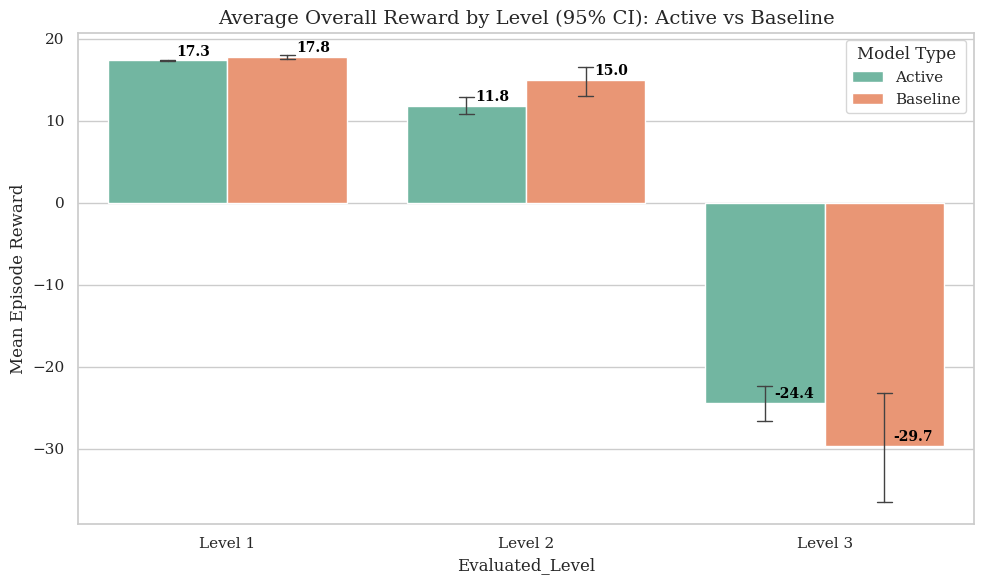

In [21]:
reward_by_level_CI(filtered_df)

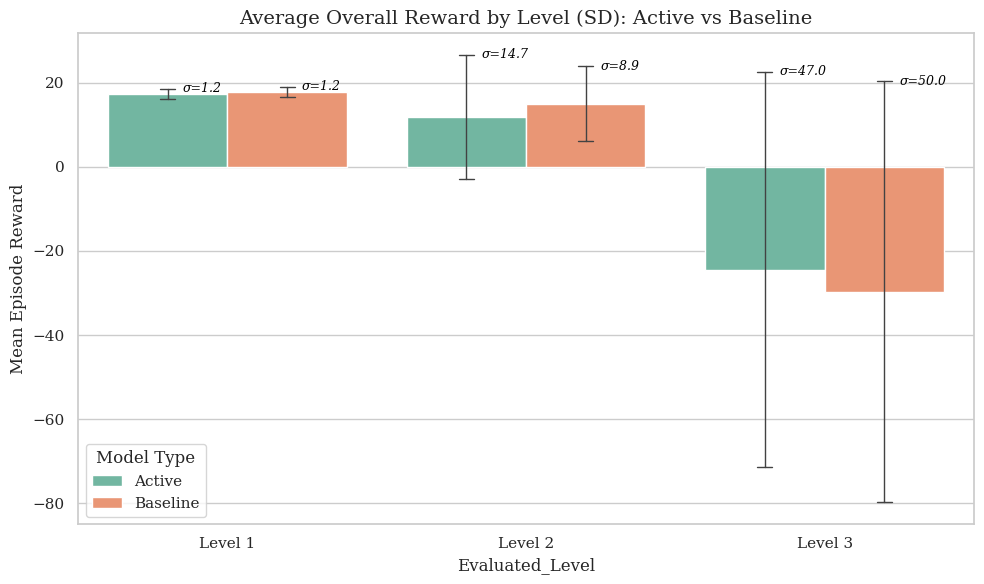

In [22]:
reward_by_level_std_dev(filtered_df)

In [29]:
# Tables

print(f"\n=== LEVEL 1 ===\n")
create_summary_tables(df_lvl_1_on_1, "Level 1", trained_level = "Level 1")
print("=================\n\n")


print(f"\n=== LEVEL 2 ===\n")
create_summary_tables(df_lvl_2_on_2, "Level 2", trained_level = "Level 2")
print("=================\n\n")


=== LEVEL 1 ===


--- Summary Table: Level 1, Trained on Level 1 | Success Threshold >= -5 ---
| Configuration     |   Mean |   SD |   Min |   Max |   Success Rate (%) |
|:------------------|-------:|-----:|------:|------:|-------------------:|
| Baseline          |  17.79 | 1.23 | 15.00 | 19.00 |             100.00 |
| Active (1% FOV)   |  18.11 | 1.60 | 15.00 | 20.00 |             100.00 |
| Active (5% FOV)   |  17.12 | 1.17 | 14.00 | 19.00 |             100.00 |
| Active (10% FOV)  |  17.15 | 0.94 | 16.00 | 18.00 |             100.00 |
| Active (20% FOV)  |  16.94 | 0.86 | 16.00 | 18.00 |             100.00 |
| Active (40% FOV)  |  17.20 | 0.91 | 16.00 | 18.00 |             100.00 |
| Active (60% FOV)  |  17.42 | 0.82 | 16.00 | 18.00 |             100.00 |
| Active (80% FOV)  |  17.18 | 0.96 | 16.00 | 19.00 |             100.00 |
| Active (100% FOV) |  17.57 | 1.44 | 16.00 | 20.00 |             100.00 |

--- Summary Table: Level 1, Trained on Level 1 | Success Threshold >= 0 ---
| 

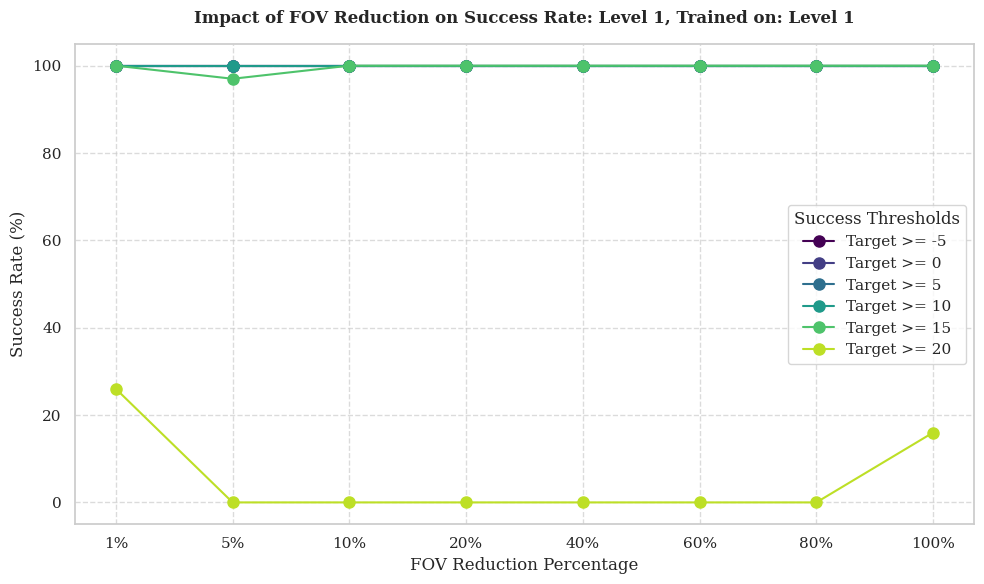

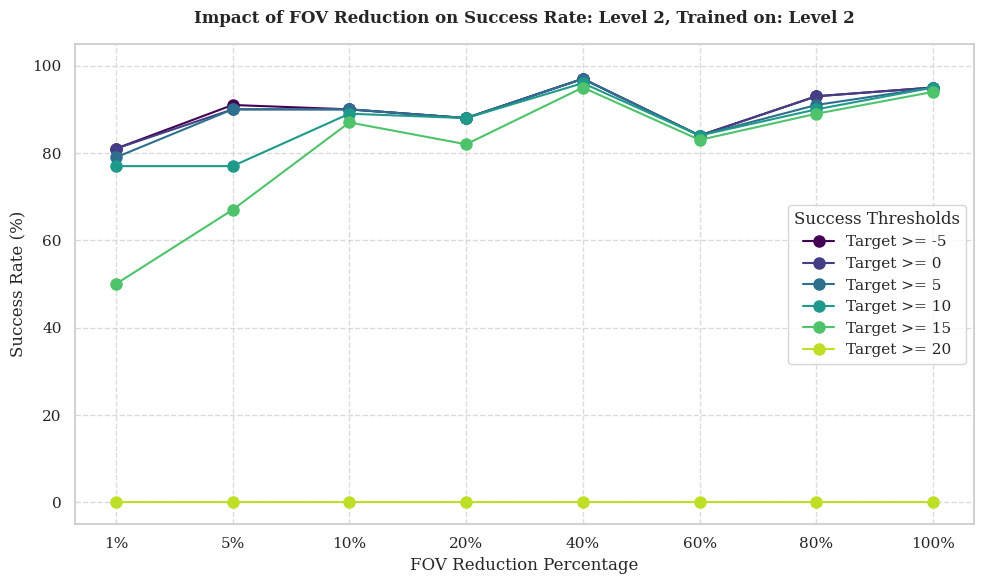

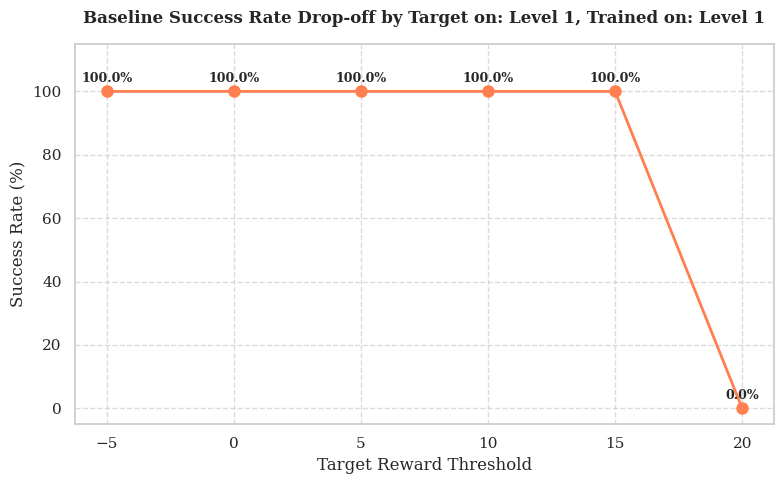

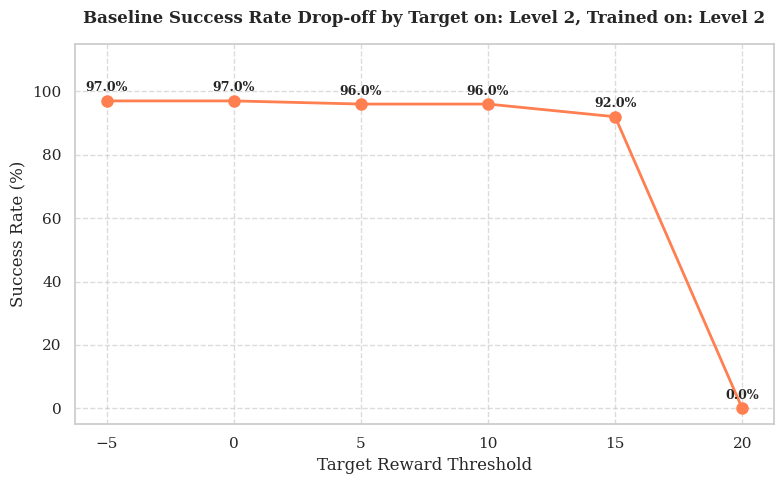

In [17]:
# Graphs
plot_success_rate_trend_from_df_active(df_lvl_1_on_1, "Level 1", "Level 1")
plot_success_rate_trend_from_df_active(df_lvl_2_on_2, "Level 2", "Level 2")

plot_success_rate_trend_baseline(df_lvl_1_on_1, "Level 1", "Level 1")
plot_success_rate_trend_baseline(df_lvl_2_on_2, "Level 2", "Level 2")

### Unseen Generalisation Evaluation


In [31]:
#Tables
create_summary_tables(df_generalisation_lvl_1_on_2, level="Level 2", trained_level = "Level 1")
create_summary_tables(df_generalisation_lvl_2_on_1, level="Level 1",  trained_level = "Level 2")

create_summary_tables(df_generalisation_lvl_1_on_3, level="Level 3", trained_level = "Level 1")
create_summary_tables(df_generalisation_lvl_2_on_3, level="Level 3", trained_level = "Level 2")


--- Summary Table: Level 2, Trained on Level 1 | Success Threshold >= -5 ---
| Configuration     |   Mean |    SD |     Min |   Max |   Success Rate (%) |
|:------------------|-------:|------:|--------:|------:|-------------------:|
| Baseline          | -28.06 | 46.19 | -124.00 | 19.00 |              41.00 |
| Active (1% FOV)   |   0.23 | 19.71 |  -89.00 | 19.00 |              65.00 |
| Active (5% FOV)   |   2.16 | 20.04 |  -65.00 | 17.00 |              62.00 |
| Active (10% FOV)  |  -1.28 | 19.10 |  -57.00 | 17.00 |              49.00 |
| Active (20% FOV)  |   1.26 | 19.19 |  -61.00 | 19.00 |              64.00 |
| Active (40% FOV)  |  -9.54 | 31.36 | -120.00 | 19.00 |              50.00 |
| Active (60% FOV)  |  -6.51 | 22.46 |  -62.00 | 17.00 |              43.00 |
| Active (80% FOV)  |   5.81 | 15.87 |  -41.00 | 19.00 |              72.00 |
| Active (100% FOV) |   2.49 | 20.08 |  -58.00 | 19.00 |              71.00 |

--- Summary Table: Level 2, Trained on Level 1 | Success Thresh

{-5:        Configuration   Mean         SD   Min   Max  Success Rate (%)
 0           Baseline   4.45  18.136060 -32.0  19.0              77.0
 1    Active (1% FOV) -12.04  25.888229 -92.0  19.0              43.0
 2    Active (5% FOV)   2.67  19.268992 -49.0  19.0              74.0
 3   Active (10% FOV)   5.89  18.388564 -40.0  19.0              76.0
 4   Active (20% FOV)  -5.10  22.212700 -51.0  19.0              56.0
 5   Active (40% FOV)   5.31  17.022679 -49.0  19.0              81.0
 6   Active (60% FOV) -17.22  17.817583 -36.0  18.0              28.0
 7   Active (80% FOV)  10.11  14.938862 -50.0  19.0              87.0
 8  Active (100% FOV)  -4.97  29.575602 -78.0  19.0              62.0,
 0:        Configuration   Mean         SD   Min   Max  Success Rate (%)
 0           Baseline   4.45  18.136060 -32.0  19.0              77.0
 1    Active (1% FOV) -12.04  25.888229 -92.0  19.0              41.0
 2    Active (5% FOV)   2.67  19.268992 -49.0  19.0              70.0
 3   Active 

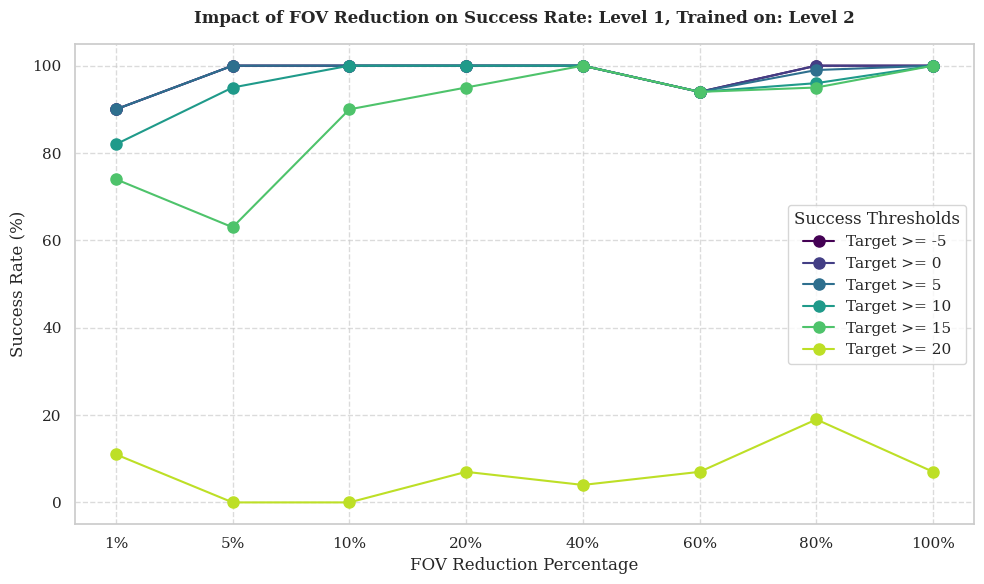

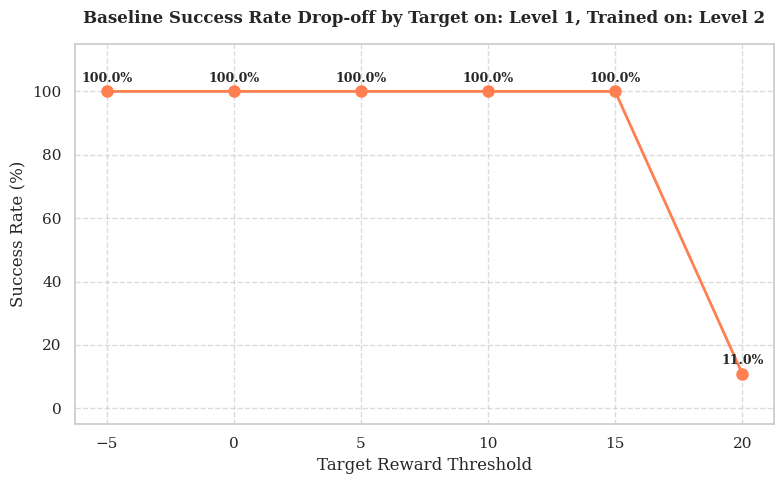

In [20]:
#Graphs
# plot_success_rate_trend_from_df_active(df_generalisation_lvl_1_on_2, level="Level 2")
# plot_success_rate_trend_baseline(df_generalisation_lvl_1_on_2, level="Level 2")

plot_success_rate_trend_from_df_active(df_generalisation_lvl_2_on_1, level="Level 1", trained_level="Level 2")
plot_success_rate_trend_baseline(df_generalisation_lvl_2_on_1, level="Level 1", trained_level="Level 2")


# plot_success_rate_trend_from_df_active(df_generalisation_lvl_1_on_3, level="Level 3")
# plot_success_rate_trend_baseline(df_generalisation_lvl_1_on_3, level="Level 3")

# plot_success_rate_trend_from_df_active(df_generalisation_lvl_2_on_3, level="Level 3",  trained_level="Level 2")
# plot_success_rate_trend_baseline(df_generalisation_lvl_2_on_3, level="Level 3", trained_level="Level 2")


In [36]:
input_file = graphs_directory  / "Evaluations" / "Summary_Tables_ALL.txt" 
output_directory = "Rendered_Tables"

# Create the output folder if it doesn't exist
Path(output_directory).mkdir(parents=True, exist_ok=True)

# 2. Parse the text file
print("Parsing text file...")
extracted_tables = parse_txt_to_dataframes(input_file)
print(f"Found {len(extracted_tables)} tables.\n")

# 3. Render and save each table
print("Rendering PDFs...")
for title, df in extracted_tables:
    save_table_as_pdf(df, title, output_directory)
    
print("\nAll tables generated successfully!")

Parsing text file...
Found 36 tables.

Rendering PDFs...
Saved: SummaryTableLevel1TrainedonLevel1_SuccessThreshold_gte_-5.pdf
Saved: SummaryTableLevel1TrainedonLevel1_SuccessThreshold_gte_0.pdf
Saved: SummaryTableLevel1TrainedonLevel1_SuccessThreshold_gte_5.pdf
Saved: SummaryTableLevel1TrainedonLevel1_SuccessThreshold_gte_10.pdf
Saved: SummaryTableLevel1TrainedonLevel1_SuccessThreshold_gte_15.pdf
Saved: SummaryTableLevel1TrainedonLevel1_SuccessThreshold_gte_20.pdf
Saved: SummaryTableLevel2TrainedonLevel2_SuccessThreshold_gte_-5.pdf
Saved: SummaryTableLevel2TrainedonLevel2_SuccessThreshold_gte_0.pdf
Saved: SummaryTableLevel2TrainedonLevel2_SuccessThreshold_gte_5.pdf
Saved: SummaryTableLevel2TrainedonLevel2_SuccessThreshold_gte_10.pdf
Saved: SummaryTableLevel2TrainedonLevel2_SuccessThreshold_gte_15.pdf
Saved: SummaryTableLevel2TrainedonLevel2_SuccessThreshold_gte_20.pdf
Saved: SummaryTableLevel2TrainedonLevel1_SuccessThreshold_gte_-5.pdf
Saved: SummaryTableLevel2TrainedonLevel1_SuccessTh

In [38]:
generate_latex_from_tables(extracted_tables) 

LaTeX code saved to All_Tables.tex
